In [1]:
from polair import _helpers as h
from polair import _calibration as calibration 
from polair import _corr_fcts as corr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml
import subprocess
import glob
import os
from scipy import signal
from scipy.signal import hilbert, find_peaks

In [ ]:
campaign_dir = "../../sanat_processing/" # SANAT
campaign_dir = "../../bacsam2_processing/" # BACSAM 2

#config_file = f"{campaign_dir}/config_sanat.yaml" # SANAT
config_file = f"{campaign_dir}/config_bacsam2.yaml" # BACSAM II

# Manual processing steps

Not all steps of the turbulence processing can be automated. The definition segment times and the calibration has to be done manually. Here is the code which can be used for this. It uses the calibrated raw data of a flight. Restart kernel when changing flight.

## Find corrupted lines

If the preprocessing doesn't work, the downloaded files are sometimes corrupted. To find the corrupted lines and remove them from the files, here are some things you can try.

In [6]:
fn = "/Users/lakoeh001/AWI/Campaigns/20260103SANAT/Daten/RF10_20260129/20260129_RF10/20260129_P6_RF10_GPS1.ATEL.dat"

In [7]:
with open(fn, "rb") as f:
    for i, line in enumerate(f, start=1):
        try:
            line.decode("utf-8")
        except UnicodeDecodeError as e:
            print(f"Unicode error in line {i}: {e}")
            print(line[:200])  # show beginning of bad line
            break


In [14]:
3881 * 2 # If the file has an empty line between every timestep, we have to double the line number since the empty lines are not imported

7762

In [111]:
# Broken indices can lead to errors.

df = pd.read_csv(fn, header  = 4, sep = r'\s+', names = ["date", "time", f"var"])
#df = h.get_timestamps(df)

In [112]:
bad_idx = [i for i, x in enumerate(df["time"]) if len(str(x)) != 15]

In [113]:
bad_idx

[]

In [116]:
# Dublicated time stamps can also lead to errors

dup_times = df.loc[df["time"].duplicated(), "time"]
dup_times

713462    19:36:42.721124
713473    19:36:45.070794
Name: time, dtype: object

df = df[df[v].str.startswith("$GPGGA")].reset_index()

ValueError: Cannot mask with non-boolean array containing NA / NaN values

In [ ]:
bad = gpgga[
    gpgga[v].str.len() < 60
]

bad

## Import the data

In [2]:
flight = 11

In [3]:
config = h.import_dictionary(config_file)
logfile = h.create_logfile(config)
vars = h.import_dictionary(config["paths"]["variables"])
out_vars = h.import_dictionary(config["paths"]["processed_variables"])
fhp_params = h.import_dictionary(config["paths"]["fiveholeprobe"])
outdir_raw = config["paths"]["outdirs"]["raw"]
outdir_nb = config["paths"]["outdirs"]["noseboom"]
flight_date = str(config["flights"][flight]["date"]).replace("-","")
campaign = config["campaign"]["name"]
fn_in = outdir_raw+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_calibrated_raw_data.nc"
fn_out = outdir_nb+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_noseboom_100Hz.nc"

data = xr.open_dataset(fn_in)

## Get start and stop

Determine start and stop time for time integration of INS and the data range provided in the final files.

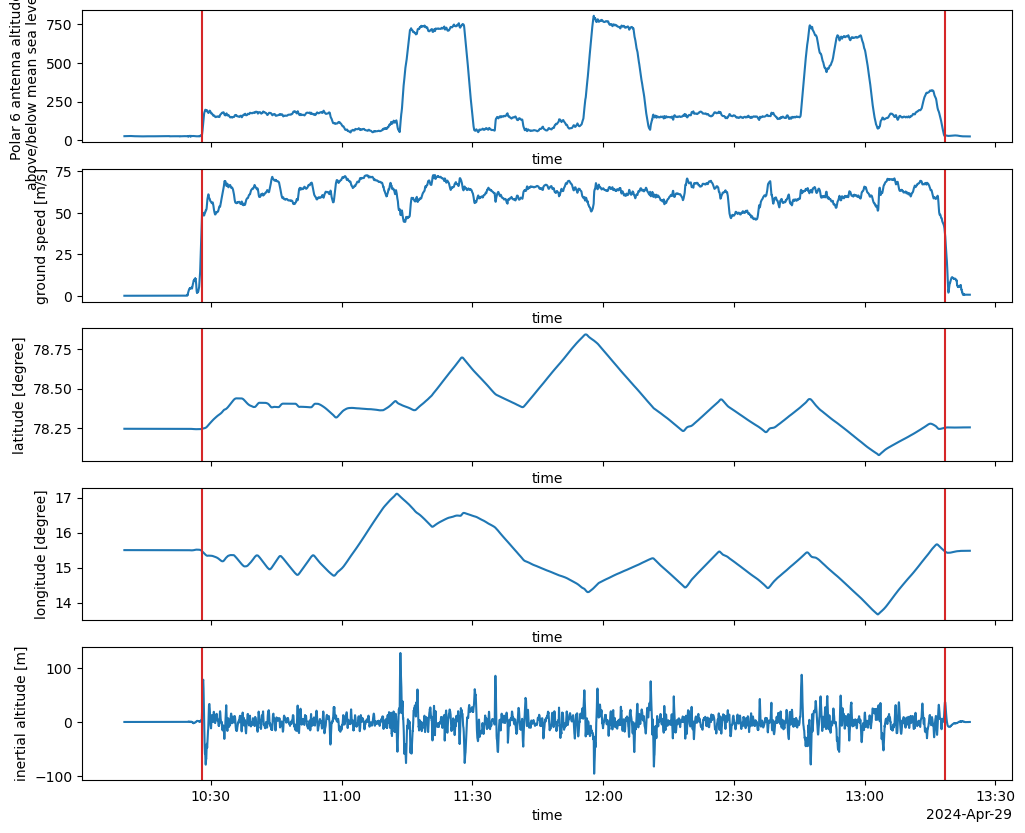

In [137]:
start = np.datetime64("2024-04-29T10:28:00")
stop = np.datetime64("2024-04-29T13:18:30")

# usefule variables: gs, h_ins, lat, lon, h_gpgga

#data.gs.plot()
fig, axs = plt.subplots(5,1,figsize=(12,10),sharex=True)

for v, ax in zip(["h_gpgga", "gs", "lat", "lon", "h"], fig.get_axes()):
    data[v].plot(ax = ax)
    ax.axvline(start, c = "tab:red")
    ax.axvline(stop, c = "tab:red")

## Get segments

Each flight is divided into segments to make it easier to work with the data.

In [142]:
# Calculate parameters useful for segment determination

start = config["flights"][flight]["start"]
stop = config["flights"][flight]["stop"]

pf = "noseboom"
twist_angle = np.deg2rad(config["campaign"]["noseboom_twist"])

for v in ["qb", "qc", "ps", "alpha", "beta"]:
    da = corr.alignement_correction(data, fhp_params, v, pf, twist_angle).rename(v)
    try:
        data_corr[v] = da
    except:
        data_corr = da.to_dataset()

# Some corrections:
data_corr["qc"] = data_corr["qc"].where(data_corr["qc"]>0, other = 0)
data_corr["alpha"] = data_corr["alpha"].where(data_corr["qc"]>500, other = 0)
data_corr["beta"] = data_corr["beta"].where(data_corr["qc"]>500, other = 0)

# adiabatic corrections for sensors in Rosemount/Goodrich housings
etaE = 1.00025  # recovery factor for deiced sensors
for temp in ["TejB", "ThuB", "Te_N", "ThuN", "TejN"]:
    name = f"{temp}_corr"
    if temp == "TejB":
        da = corr.sat_correction(data, data_corr, temp, recovery=etaE).rename(name)
    else:
        da = corr.sat_correction(data, data_corr, temp).rename(name)
    try:
        data_corr[name] = da
    except:
        data_corr = da.to_dataset()

# Correct relative humidity using the Magnus formula for the saturation pressure.
rh_corr = corr.humidity_correction(data.rFHuN, data.ThuN, data_corr.Te_N_corr)
data_corr["rFHuN_corr"] = rh_corr

# Correction of INS with GPS
w_ins = corr.get_w_ins(data, start, stop)
h_ins = corr.get_h_ins(w_ins["w_ins"])
data = xr.merge([data, w_ins, h_ins])

for v in ["lat", "lon", "gs", "h_ins", "w_ins", "vew", "vns"]:
    gps_corr = corr.correct_ins_with_gps(data, v)
    data_corr = xr.merge([data_corr, gps_corr])

ttrk_corr = corr.correct_ttrk_ins_with_gps(data, data_corr, "ttrk")
data_corr = xr.merge([data_corr, ttrk_corr])

# Calculate true airspeed
data_corr["tas"] = corr.get_true_air_speed(data_corr, pf)

for v in ["u", "v", "vertwind"]:
    wind_comp = corr.get_wind_component(data, data_corr, v, pf)
    data_corr[v] = wind_comp

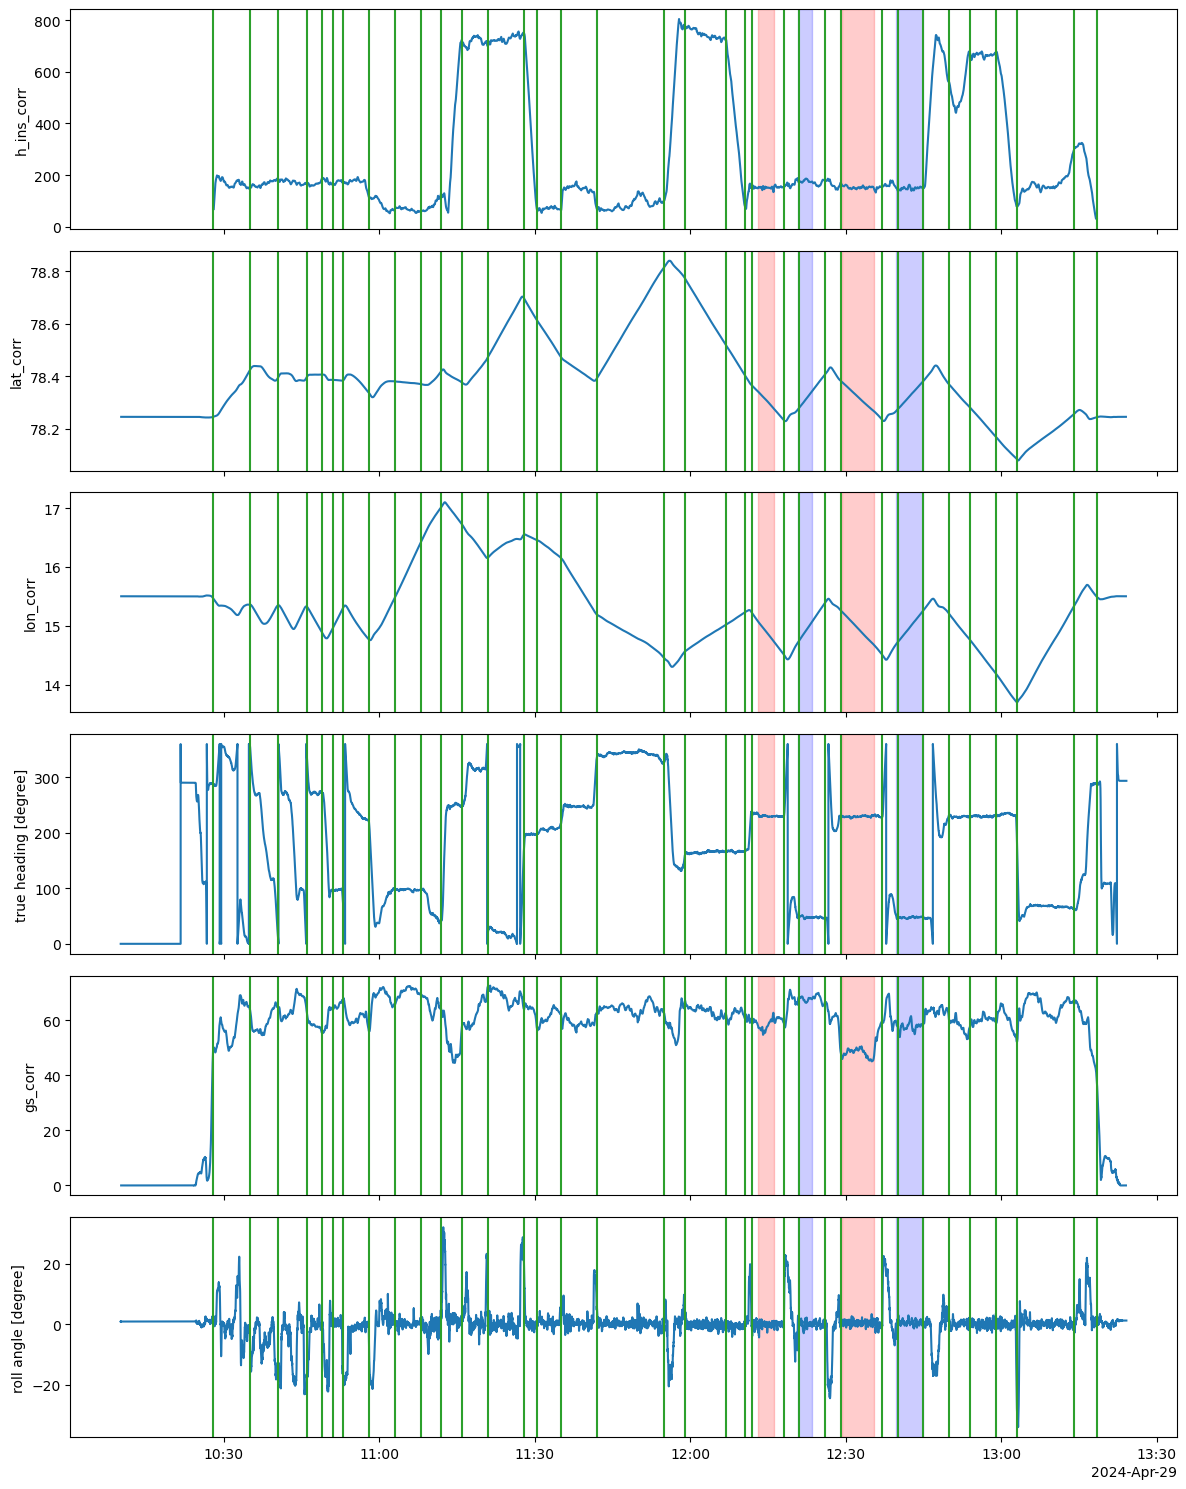

In [180]:
fig, axs = plt.subplots(6,1,figsize=(12,15),sharex=True)

data_corr.h_ins_corr.plot(ax = axs[0])
data_corr.lat_corr.plot(ax = axs[1])
data_corr.lon_corr.plot(ax = axs[2])
data.thdg.plot(ax = axs[3])
data_corr.gs_corr.plot(ax = axs[4])
data["roll"].plot(ax = axs[5])

seglist = []

calsegs = []

# If segments are aleady determined, it is possible to plot them here with the switch:
if 1:
    try:
        seg_fn = config["paths"]["segments"]
        segments = h.import_dictionary(seg_fn)
        flight_segments = segments["flights"][flight]["segments"]
        for i in np.arange(len(flight_segments)):
            t = flight_segments[i]['time']
            seglist.append(t)
    except:
        print("No segment file available")

seglist = np.array(seglist).astype("datetime64")
calsegs = np.array(calsegs).astype("datetime64")

for ax in fig.get_axes():
    ax.set_xlabel("")
    for s in seglist:
        ax.axvline(s, color = "tab:green")
    for cal in calsegs:
        ax.axvline(cal, color = "tab:red")

# If calibration segments are already available:
for ax in fig.get_axes():
    for key, val in cal_segs.items():
        start = val['start']
        stop = val['stop']
        
        # optional: different colors for "out" vs "ret"
        color = 'red' if 'out' in key else 'blue'
        
        ax.axvspan(start, stop, alpha=0.2, color=color)

plt.tight_layout()

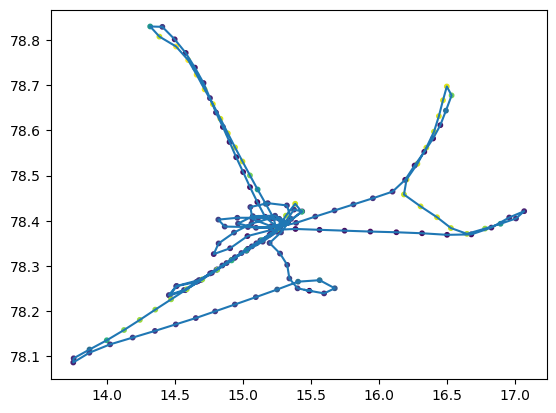

In [197]:
# The flight track might also be useful for the segemnts:

min = data_corr.resample(time = "1min").mean()

plt.plot(min.lon_corr, min.lat_corr)
plt.scatter(min.lon_corr, min.lat_corr, c=min.h_ins_corr.values, s=10, cmap="viridis")

#### Identification of calibration segments:

Calibration segments are mainly identified looking at the segmentation above. However, it might be helpful to look at the out and ret part and see if they fit together.

In [198]:
seg_a = slice("2024-04-29T12:13:10", "2024-04-29T12:16:12")
seg_b = slice("2024-04-29T12:20:50", "2024-04-29T12:23:27")

In [211]:
print(f"out: alt = {data_corr.sel(time = seg_a).h_ins_corr.mean().values:.3f}, tas = {data_corr.sel(time = seg_a).tas.mean().values:.3f}, thdg = {data.sel(time = seg_a).thdg.mean().values:.2f}, lat = {data_corr.sel(time = seg_a).lat_corr.values[0]:.3f}-{data_corr.sel(time = seg_a).lat_corr.values[-1]:.3f}, lon = {data_corr.sel(time = seg_a).lon_corr.values[0]:.3f}-{data_corr.sel(time = seg_a).lon_corr.values[-1]:.3f}")
print(f"ret: alt = {data_corr.sel(time = seg_b).h_ins_corr.mean().values:.3f}, tas = {data_corr.sel(time = seg_b).tas.mean().values:.3f}, thdg + 180 = {((data.sel(time = seg_b).thdg.mean().values + 180)%360):.2f}, lat = {data_corr.sel(time = seg_b).lat_corr.values[-1]:.3f}-{data_corr.sel(time = seg_b).lat_corr.values[0]:.3f}, lon = {data_corr.sel(time = seg_b).lon_corr.values[-1]:.3f}-{data_corr.sel(time = seg_b).lon_corr.values[0]:.3f}")

out: alt = 150.061, tas = 61.655, thdg = 229.88, lat = 78.341-78.275, lon = 15.063-14.723
ret: alt = 176.438, tas = 62.196, thdg + 180 = 228.05, lat = 78.342-78.276, lon = 15.062-14.722


### Segmentation documentation

For the GitHub Repos, I want to transform the segmentation list in an html table.

In [7]:
# This is for having a csv file with the times and the segment types and comments. There might be a more elegant way to do this, maybe adjust for the next campaign.

#fn_in = "/Users/lakoeh001/AWINextcloud/personal/lakoeh001/campaigns/2026sanat/flights/SANAT_FlightSegments.csv"
fn_in = "/Users/lakoeh001/AWINextcloud/personal/lakoeh001/campaigns/2024bacsam2/BACSAM2FlightSegmentTypes.csv"
df = pd.read_csv(fn_in, sep = ";")
byflight = df.groupby(by = "Flight")

In [8]:
flight_dict = {}
#flights = [11,12,21,22,31,32,33,4,5,6,7,8,9,10] # SANAT
flights = [1,2,3,40,41,42,5,6,7,8,9,10,11] # BACSAM II
for f in flights:
    selected_flight = byflight.get_group(f)
    flight_list = []
    for i in np.arange(len(selected_flight)):
        seg_info = selected_flight.iloc[i]
        if type(seg_info["Comment"]) == type("str"):
            comment = seg_info["Comment"]
        else:
            comment = ""
        segs = {"segment" : int(seg_info["Segment"]), "time": seg_info["Time"], "type": seg_info["Type"], "comment": comment}
        flight_list.append(segs)
    flight_dict[f] = {"segments": flight_list}

flight_segments = {"flights": flight_dict}

In [9]:
#fn_out = "/Users/lakoeh001/AWI/Programmierung/sanat_processing/sanat_flight_segments.yaml" # SANAT
fn_out = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/bacsam2_flight_segements.yaml" # BACSAM II
with open(fn_out, 'w') as file:
    yaml.safe_dump(flight_segments, file, sort_keys=False)

In [10]:
def generate_html_table(data, output_file):
    html = []

    html.append('<table style="font-size:90%; border-collapse:collapse;">')

    html.append("""
<thead>
<tr>
<th>Flight</th>
<th>Segment</th>
<th>Time</th>
<th>Type</th>
<th>Comment</th>
</tr>
</thead>
<tbody>
""")

    for flight_id, flight_data in data["flights"].items():

        segments = flight_data["segments"]
        rowspan = len(segments)

        for i, seg in enumerate(segments):

            html.append("<tr>")

            # Only write flight number once with rowspan
            if i == 0:
                html.append(f'<td rowspan="{rowspan}">{flight_id}</td>')

            html.append(f"<td>{seg['segment']}</td>")
            html.append(f"<td>{seg['time']}</td>")
            html.append(f"<td>{seg['type']}</td>")
            html.append(f"<td>{seg.get('comment', '')}</td>")

            html.append("</tr>")

    html.append("</tbody></table>")

    with open(output_file, "w") as f:
        f.write("\n".join(html))

    print(f"HTML table written to {output_file}")

In [11]:
# SANAT
#fn_flightsegs = "/Users/lakoeh001/AWI/Programmierung/sanat_processing/sanat_flight_segments.yaml"
#fn_html_out = "/Users/lakoeh001/AWI/Programmierung/sanat_processing/sanat_flight_segments.html"

# BACSAM II
fn_flightsegs = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/bacsam2_flight_segements.yaml"
fn_html_out = "/Users/lakoeh001/AWI/Programmierung/bacsam2_processing/bacsam2_flight_segements.html"

with open(fn_flightsegs) as f:
    segments = yaml.safe_load(f)

generate_html_table(segments, fn_html_out)

HTML table written to /Users/lakoeh001/AWI/Programmierung/bacsam2_processing/bacsam2_flight_segements.html


## Noseboom calibration

### dynamic pressure q

We do this according to the explanation in Hartmann 2018.

In [55]:
def get_rho(ds, ds_proc):
    Rs = 287.0528
    rho = ds.psN / (Rs * ds_proc.t_air)
    return rho

In [56]:
outdir_raw = config["paths"]["outdirs"]["raw"]
outdir_nb = config["paths"]["outdirs"]["noseboom"]
campaign = config["campaign"]["name"]

In [57]:
qref = []
qi = np.array([])
gammaout = np.array([])
gammaret = np.array([])

for flight in list(config["flights"].keys()):
    flight_date = str(config["flights"][flight]["date"]).replace("-","")
    fn_in = outdir_raw+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_calibrated_raw_data.nc"
    data = xr.open_dataset(fn_in)
    fn_out = outdir_nb+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_noseboom_100Hz.nc"
    data_proc = xr.open_dataset(fn_out)
    try:
        cal_segments = config["flights"][flight]["calibration"]
        num = int(len(cal_segments)/2 + 1)
        for j in np.arange(1,num):
            out = data.sel(time = slice(cal_segments[f"out{j}"]["start"],cal_segments[f"out{j}"]["stop"]))
            ret = data.sel(time = slice(cal_segments[f"ret{j}"]["start"],cal_segments[f"ret{j}"]["stop"]))
            out_proc = data_proc.sel(time = slice(cal_segments[f"out{j}"]["start"],cal_segments[f"out{j}"]["stop"]))
            ret_proc = data_proc.sel(time = slice(cal_segments[f"ret{j}"]["start"],cal_segments[f"ret{j}"]["stop"]))

            out_proc["gs_corr"] = out_proc["gs"]
            ttrk_out = corr.correct_ttrk_ins_with_gps(out, out_proc,"ttrk")
            ret_proc["gs_corr"] = ret_proc["gs"]
            ttrk_ret = corr.correct_ttrk_ins_with_gps(ret, ret_proc,"ttrk")

            gamma_out = (np.deg2rad(out.thdg - ttrk_out.ttrk_corr)).mean()
            gammaout = np.append(gammaout, gamma_out.values)
            gamma_ret = (np.deg2rad(ret.thdg - ttrk_ret.ttrk_corr)).mean()
            gammaret = np.append(gammaret, gamma_ret.values)
            v_ref = 0.5 * (out_proc.gs.mean()/np.cos(gamma_out) + ret_proc.gs.mean()/np.cos(gamma_ret))
            rho = (get_rho(out, out_proc).mean() + get_rho(ret, ret_proc).mean())*0.5
            q_ref = 0.5 * rho * v_ref**2
            qref = np.append(qref, q_ref.values)
            q_i = (out.qcN.mean() + ret.qcN.mean())/2
            qi = np.append(qi, q_i.values)
    except:
        pass

In [59]:
# If fitted without offset as linear function, use this:
m = np.sum(qi * qref) / np.sum(qi * qi)
b = 0

In [60]:
m

1.0547199522286508

In [61]:
b

0

In [13]:
fit = [b , b+ qi.max() * m ]

Text(0, 0.5, '$q_\\text{ref}$ (Pa)')

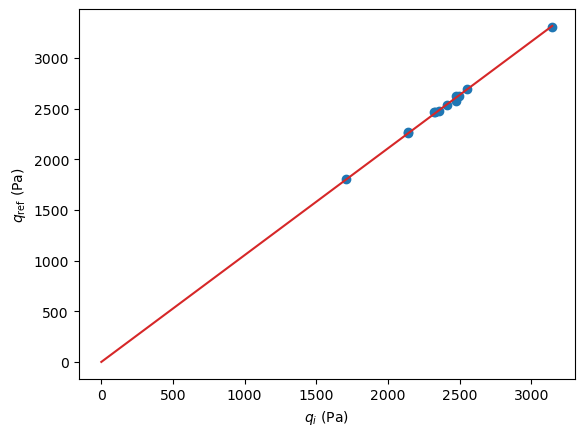

In [14]:
plt.scatter(qi, qref)
plt.plot([0, qi.max()], fit, c = "tab:red")
plt.xlabel(r"$q_i$ (Pa)")
plt.ylabel(r"$q_\text{ref}$ (Pa)")

#plt.savefig("q_fit.pdf")

Text(0, 0.5, '$\\gamma_\\text{ret}$ (˚)')

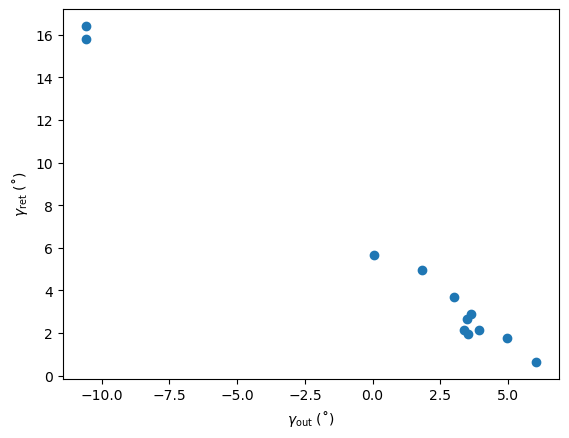

In [292]:
# This is a crosscheck if gamma_out and gamma_ret are consistent

plt.scatter(np.rad2deg(gammaout), np.rad2deg(gammaret))
#plt.plot([-12,6],[-12,6], c = "tab:red")
plt.xlabel(r"$\gamma_\text{out}$ (˚)")
plt.ylabel(r"$\gamma_\text{ret}$ (˚)")

### alpha

The alpha calibration is also explained in Hartmann et al 2028.

CPU times: user 11.4 s, sys: 1.73 s, total: 13.2 s
Wall time: 11 s


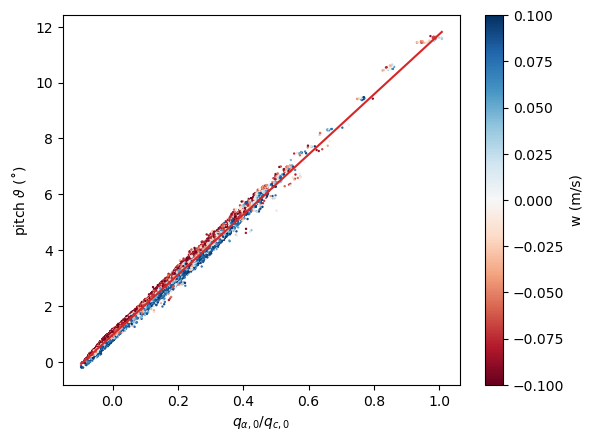

In [96]:
%%time

all_flights = [1, 2, 3, 40, 41, 42, 6, 7, 8, 9, 10, 11] # BACSAM 2, adjust for each campaign

wcut = 0.1
waircraft_cut = 0.05
roll_max = 2

pitch_list = []
qratio_list = []
scatter_handles = []

for flight in all_flights:
    start = config["flights"][flight]["start"]
    stop = config["flights"][flight]["stop"]
    flight_date = str(config["flights"][flight]["date"]).replace("-","")
    fn_in = outdir_raw+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_calibrated_raw_data.nc"
    fn_out = outdir_nb+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_noseboom_100Hz.nc"

    data = xr.open_dataset(fn_in)
    data_proc = xr.open_dataset(fn_out)
    # Align datasets to common time axis before masking
    data, data_proc = xr.align(data, data_proc, join="inner")

    w_ins = corr.get_w_ins(data, start, stop)
    ds = xr.merge([data, w_ins])
    w_p6 = corr.correct_ins_with_gps(ds, "w_ins")

    # Build mask once, apply without drop=True
    mask = (
        (np.abs(data_proc.w) < wcut) &
        (np.abs(w_p6.w_ins_corr) < waircraft_cut) &
        (np.abs(ds["roll"]) < roll_max)
    )
    mask_vals = mask.values

    pitch  = ds.pit.values[mask_vals]
    qratio = (ds.qaN / ds.qcN).values[mask_vals]
    w_proc = data_proc.w.values[mask_vals]

    pitch_list.append(pitch)
    qratio_list.append(qratio)

    sc = plt.scatter(qratio, pitch, s=0.5, c=w_proc, vmin=-wcut, vmax=wcut, cmap="RdBu")
    scatter_handles.append(sc)

# Concatenate once at the end instead of appending in loop
pitch_all  = np.concatenate(pitch_list)
qratio_all = np.concatenate(qratio_list)

plt.xlabel(r"$q_{\alpha,0}/q_{c,0}$")
plt.ylabel(r"pitch $\vartheta$ (˚)")
plt.colorbar(scatter_handles[-1], label="w (m/s)")

mask_finite = np.isfinite(qratio_all) & np.isfinite(pitch_all)
m, c = np.polyfit(qratio_all[mask_finite], pitch_all[mask_finite], 1)
fit = [qratio_all.min() * m + c, qratio_all.max() * m + c]
plt.plot([qratio_all.min(), qratio_all.max()], fit, c="tab:red")

#plt.savefig("alpha_fit.png")

In [97]:
m

10.768612544746063

In [94]:
c

0.9604719213925181

### beta_0

In [19]:
pf = "noseboom"

In [98]:
calib_fn = f"{campaign_dir}/turbulence/fiveholeprobe_parameters_bacsam2.yaml"

def set_beta0(beta0):
    with open(calib_fn, "r") as f:
        calib = yaml.safe_load(f)
    calib[pf]["beta"]["a0"] = float(beta0)
    with open(calib_fn, "w") as f:
        yaml.dump(calib, f)

def delete_output_files():
    patterns = [
        outdir_nb + f"/{campaign}_*_noseboom_100Hz.nc",
    ]
    for pattern in patterns:
        for fn in glob.glob(pattern):
            os.remove(fn)
            print(f"Deleted: {fn}")

def run_polair():
    flights = "1 8 9 10 11"
    for flight in flights.split():
        subprocess.run(
            f"polair noseboom -f {flight} -c {config_file}",
            shell=True, check=True
        )

def compute_score():
    uperp_cals = []
    upara_cals = []
    
    for flight in [1, 8, 9, 10, 11]:
        flight_date = str(config["flights"][flight]["date"]).replace("-", "")
        fn_in  = outdir_raw + "/" + campaign + "_" + flight_date + f"_RF{flight:02}_calibrated_raw_data.nc"
        fn_out = outdir_nb + "/" + campaign + "_" + flight_date + f"_RF{flight:02}_noseboom_100Hz.nc"
        
        data      = xr.open_dataset(fn_in)
        data_proc = xr.open_dataset(fn_out)
        cal_segments = config["flights"][flight]["calibration"]
        num = int(len(cal_segments) / 2 + 1)
        
        for j in np.arange(1, num):
            uperp_sum = 0
            upara_sum = 0
            for dir in ["out", "ret"]:
                seg = cal_segments[f"{dir}{j}"]
                ds      = data.sel(time=slice(seg["start"], seg["stop"]))
                ds_proc = data_proc.sel(time=slice(seg["start"], seg["stop"]))
                thdg_rad = np.deg2rad(ds.thdg)
                uperp = ds_proc.u * np.cos(thdg_rad) - ds_proc.v * np.sin(thdg_rad)
                upara = ds_proc.u * np.sin(thdg_rad) + ds_proc.v * np.cos(thdg_rad)
                
                uperp_sum += uperp.mean().values
                upara_sum += upara.mean().values
            
            uperp_cals.append(uperp_sum)
            upara_cals.append(upara_sum)
    
    score_uperp = np.mean(np.abs(uperp_cals))
    score_upara = np.mean(np.abs(upara_cals))
    print(f"  mean|uperp| = {score_uperp:.4f},  mean|upara| = {score_upara:.4f}")
    return score_uperp, score_upara

In [100]:
# --- Main loop ---
beta0_values = np.linspace(-2.9,-2.7,21)
results = {}

for beta0 in beta0_values:
    print(f"\n--- beta0 = {beta0:.2f} ---")
    set_beta0(beta0)
    delete_output_files()
    run_polair()
    score_uperp, score_upara = compute_score()  # unpack tuple
    results[float(beta0)] = (score_uperp, score_upara)

best_beta0 = min(results, key=lambda b: results[b][0])
print(f"\nBest beta0: {best_beta0:.2f}  (uperp={results[best_beta0][0]:.4f}, upara={results[best_beta0][1]:.4f})")


--- beta0 = -2.90 ---
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240424_RF08_noseboom_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240407_RF01_noseboom_100Hz.nc
  mean|uperp| = 0.8066,  mean|upara| = 1.4939

--- beta0 = -2.89 ---
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240426_RF10_noseboom_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240425_RF09_noseboom_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240424_RF08_noseboom_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240407_RF01_noseboom_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/noseboom/BACSAM2_20240429_RF11_noseboom_100Hz.nc
  mean|uperp| = 0.8038,  m

In [101]:
set_beta0(best_beta0)

In [102]:
results

{-2.9: (0.8066260218438291, 1.4938647216438152),
 -2.89: (0.8037527274173163, 1.4938414626602554),
 -2.88: (0.800879394174116, 1.4938180666097807),
 -2.87: (0.7980060222017533, 1.4937945334931009),
 -2.86: (0.7951326115877547, 1.4937708633109346),
 -2.85: (0.7922591624196528, 1.493747056064002),
 -2.84: (0.7893856747849736, 1.4937231117530299),
 -2.83: (0.786512148771252, 1.4936990303787459),
 -2.82: (0.7836385844660191, 1.4936748119418848),
 -2.81: (0.7807649819568093, 1.4936504564431832),
 -2.8: (0.7778913413311569, 1.4936259638833838),
 -2.79: (0.7753921230634826, 1.4936013342632328),
 -2.7800000000000002: (0.7777887074650024, 1.493656836992723),
 -2.77: (0.7827604727794178, 1.4939204006117748),
 -2.7600000000000002: (0.7877322746077331, 1.4942767423588679),
 -2.75: (0.7927041127984994, 1.494631773733781),
 -2.74: (0.7976759872002654, 1.4949854947256995),
 -2.73: (0.8026478976615786, 1.495337905323848),
 -2.72: (0.8076198440309862, 1.495689005517492),
 -2.71: (0.8125918261570342, 1.

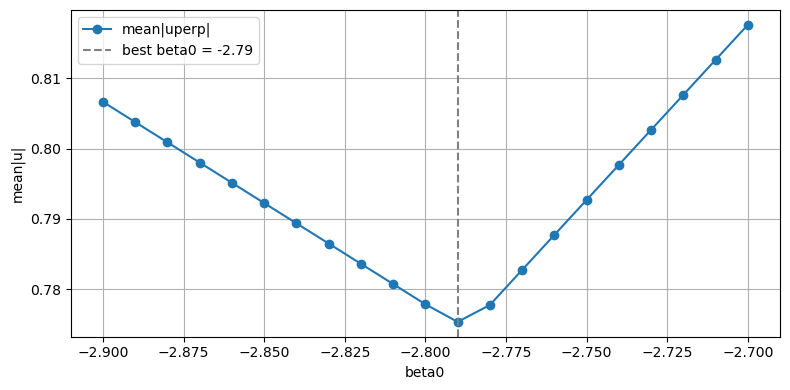

In [103]:
beta0s      = list(results.keys())
score_uperp = [results[b][0] for b in beta0s]
score_upara = [results[b][1] for b in beta0s]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(beta0s, score_uperp, marker="o", label="mean|uperp|")
#ax.plot(beta0s, score_upara, marker="o", label="mean|upara|")
ax.axvline(best_beta0, color="gray", linestyle="--", label=f"best beta0 = {best_beta0:.2f}")
ax.set_xlabel("beta0")
ax.set_ylabel("mean|u|")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#fig.savefig("beta0_determination.pdf")

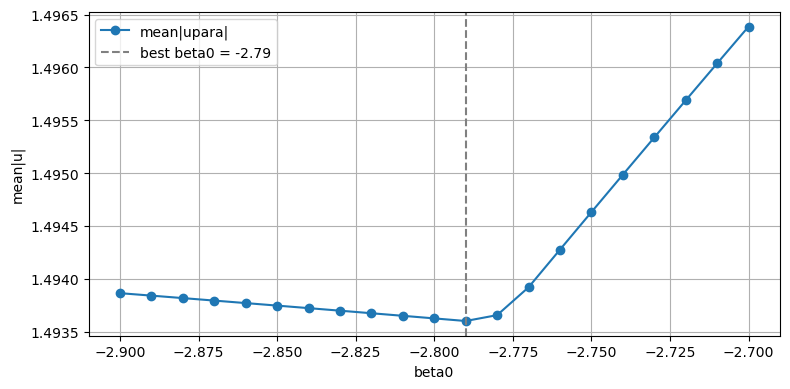

In [104]:
beta0s      = list(results.keys())
score_uperp = [results[b][0] for b in beta0s]
score_upara = [results[b][1] for b in beta0s]

fig, ax = plt.subplots(figsize=(8, 4))
#ax.plot(beta0s, score_uperp, marker="o", label="mean|uperp|")
ax.plot(beta0s, score_upara, marker="o", label="mean|upara|")
ax.axvline(best_beta0, color="gray", linestyle="--", label=f"best beta0 = {best_beta0:.2f}")
ax.set_xlabel("beta0")
ax.set_ylabel("mean|u|")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## T-Bird calibration

### dynamic pressure T-Bird

In [243]:
flights_with_calibration = [8, 9] # BACSAM 2, adjust for each campaign
flights_with_tbird = [41, 5, 6, 7, 8, 9] # BACSAM 2, adjust for each campaign

In [244]:
def get_rho(ds, ds_proc):
    Rs = 287.0528
    rho = ds.psT / (Rs * ds_proc.t_air)
    return rho

In [245]:
outdir_raw = config["paths"]["outdirs"]["raw"]
outdir_tb = config["paths"]["outdirs"]["tbird"]
campaign = config["campaign"]["name"]

In [276]:
qref = []
qi = np.array([])
gammaout = np.array([])
gammaret = np.array([])

for flight in flights_with_tbird:
    flight_date = str(config["flights"][flight]["date"]).replace("-","")
    fn_in = outdir_raw+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_calibrated_raw_data.nc"
    data = xr.open_dataset(fn_in)
    fn_out = outdir_tb+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_tbird_100Hz.nc"
    data_proc = xr.open_dataset(fn_out)
    try:
        cal_segments = config["flights"][flight]["calibration"]
        num = int(len(cal_segments)/2 + 1)
        for j in np.arange(1,num):
            out = data.sel(time = slice(cal_segments[f"out{j}"]["start"],cal_segments[f"out{j}"]["stop"]))
            ret = data.sel(time = slice(cal_segments[f"ret{j}"]["start"],cal_segments[f"ret{j}"]["stop"]))
            out_proc = data_proc.sel(time = slice(cal_segments[f"out{j}"]["start"],cal_segments[f"out{j}"]["stop"]))
            ret_proc = data_proc.sel(time = slice(cal_segments[f"ret{j}"]["start"],cal_segments[f"ret{j}"]["stop"]))

            out_proc["ttrk_inat_corr"] = out.ttrk_inat
            ttrk_out = corr.correct_ttrk_inat_with_gps(out, out_proc)
            ret_proc["ttrk_inat_corr"] = ret.ttrk_inat
            ttrk_ret = corr.correct_ttrk_inat_with_gps(ret, ret_proc)
            
            gamma_out = (np.deg2rad(out.thdg_inat - ttrk_out.ttrk_inat_corr)).mean()
            gammaout = np.append(gammaout, gamma_out.values)
            gamma_ret = (np.deg2rad(ret.thdg_inat - ttrk_ret.ttrk_inat_corr)).mean()
            gammaret = np.append(gammaret, gamma_ret.values)
            v_ref = 0.5 * (out_proc.gs.mean()/np.cos(gamma_out) + ret_proc.gs.mean()/np.cos(gamma_ret))
            rho = (get_rho(out, out_proc).mean() + get_rho(ret, ret_proc).mean())*0.5
            q_ref = 0.5 * rho * v_ref**2
            qref = np.append(qref, q_ref.values)
            q_i = (out.qcT.mean() + ret.qcT.mean())/2
            qi = np.append(qi, q_i.values)
    except:
        pass

In [8]:
# If fitted with offset use this:
m, b = np.polyfit(qi, qref, 1)

In [277]:
# If fitted without offset as linear function, use this:
m = np.sum(qi * qref) / np.sum(qi * qi)
b = 0

In [278]:
m

1.200957120362395

In [279]:
b

0

In [280]:
fit = [b , b+ qi.max() * m ]

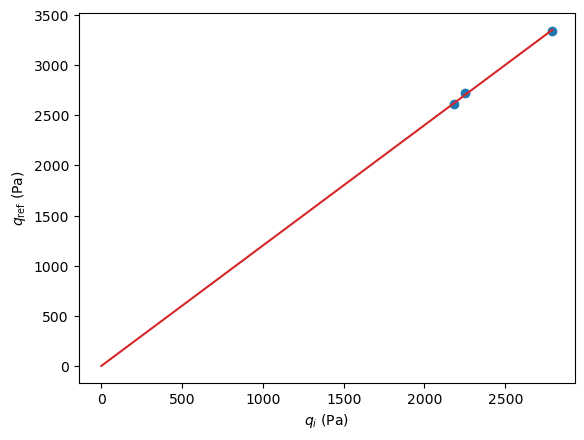

In [281]:
plt.scatter(qi, qref)
plt.plot([0, qi.max()], fit, c = "tab:red")
plt.xlabel(r"$q_i$ (Pa)")
plt.ylabel(r"$q_\text{ref}$ (Pa)")

#plt.savefig("q_fit_tbird.pdf")

### alpha T-Bird

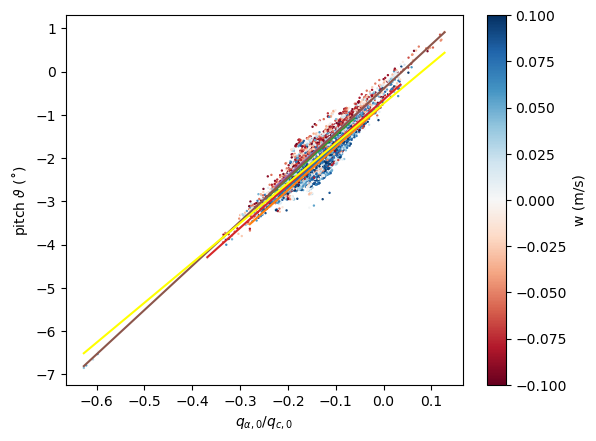

In [282]:
flights_with_tbird = [41, 5, 6, 7, 8, 9] # BACSAM 2, adjust for each campaign
wcut = 0.1
waircraft_cut = 0.05
roll_max = 2
pitch_list = []
qratio_list = []
scatter_handles = []
m_flights = []
c_flights = []

# I only take straight segments for BACSAM 2, adjust for each campaign
segments_dict = {
    41: [3, 5, 7, 9, 11, 13, 15, 17],
    5:  [7, 9, 11],
    6:  [4, 6, 8, 12, 14],
    7:  [6, 8, 10, 13, 15],
    8:  [12, 14, 16],
    9:  [4, 6, 8, 10, 12, 14],
}

for flight in [41, 5, 6, 7, 8, 9]:
    flight_date = str(config["flights"][flight]["date"]).replace("-", "")
    fn_in  = outdir_raw+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_calibrated_raw_data.nc"
    fn_out = outdir_tb +"/"+campaign+"_"+flight_date+f"_RF{flight:02}_tbird_100Hz.nc"
    data      = xr.open_dataset(fn_in).load()
    data_proc = xr.open_dataset(fn_out).load()

    # Select segments
    seg_mask = np.isin(data_proc.segment.values, segments_dict[flight])
    data_proc = data_proc.isel(time=seg_mask)

    # Match data to data_proc time axis — fast nearest-neighbor lookup
    data = data.sel(time=data_proc.time, method="nearest")

    # Compute w_inat in numpy directly
    h = data.h_inat.values
    w_inat = np.empty_like(h)
    w_inat[:-1] = np.diff(h) / 0.01
    w_inat[-1]  = np.nan

    # Build mask in numpy
    mask_vals = (
        (np.abs(data_proc.w.values) < wcut) &
        (np.abs(w_inat) < waircraft_cut) &
        (np.abs(data.roll_inat.values) < roll_max)
    )

    pitch  = -data.pitch_inat.values[mask_vals]
    qratio = (data.qaT.values / data.qcT.values)[mask_vals]
    w_proc = data_proc.w.values[mask_vals]

    pitch_list.append(pitch)
    qratio_list.append(qratio)

    # Per-flight fit
    mf = np.isfinite(qratio) & np.isfinite(pitch)
    m_f, c_f = np.polyfit(qratio[mf], pitch[mf], 1)
    m_flights.append(m_f)
    c_flights.append(c_f)

    sc = plt.scatter(qratio, pitch, s=0.5, c=w_proc, vmin=-wcut, vmax=wcut, cmap="RdBu")
    scatter_handles.append(sc)
    fit = [qratio.min() * m_f + c_f, qratio.max() * m_f + c_f]
    plt.plot([qratio.min(), qratio.max()], fit)

# Concatenate and overall fit
pitch_all  = np.concatenate(pitch_list)
qratio_all = np.concatenate(qratio_list)

mask_finite = np.isfinite(qratio_all) & np.isfinite(pitch_all)
m, c = np.polyfit(qratio_all[mask_finite], pitch_all[mask_finite], 1)
fit = [qratio_all.min() * m + c, qratio_all.max() * m + c]

plt.xlabel(r"$q_{\alpha,0}/q_{c,0}$")
plt.ylabel(r"pitch $\vartheta$ (˚)")
plt.colorbar(scatter_handles[-1], label="w (m/s)")
plt.plot([qratio_all.min(), qratio_all.max()], fit, c="yellow")

#plt.savefig("alpha_fit_tbird.png")

In [258]:
m # starting point 10 and -0.5

9.229596451686875

In [259]:
np.mean(m_flights) # starting point 10 and -0.5

9.977509593057327

In [260]:
np.mean(c_flights) # starting point 10 and -0.5

-0.5675842719854689

In [261]:
c # starting point 10 and -0.5

-0.7380858109166986

This is the error between iNAT and five hole probe.

### beta_0 T-Bird

In [235]:
pf = "tbird"

calib_fn = f"{campaign_dir}/turbulence/fiveholeprobe_parameters_bacsam2.yaml"

def set_beta0(beta0):
    with open(calib_fn, "r") as f:
        calib = yaml.safe_load(f)
    calib[pf]["beta"]["a0"] = float(beta0)
    with open(calib_fn, "w") as f:
        yaml.dump(calib, f)

def delete_output_files():
    patterns = [
        outdir_tb + f"/{campaign}_*_tbird_100Hz.nc",
    ]
    for pattern in patterns:
        for fn in glob.glob(pattern):
            os.remove(fn)
            print(f"Deleted: {fn}")

def run_polair():
    flights = [8, 9]
    for flight in flights:
        subprocess.run(
            f"polair tbird -f {flight} -c {config_file}",
            shell=True, check=True
        )

def compute_score():
    uperp_cals = []
    upara_cals = []
    
    for flight in [8, 9]:
        flight_date = str(config["flights"][flight]["date"]).replace("-", "")
        fn_in  = outdir_raw + "/" + campaign + "_" + flight_date + f"_RF{flight:02}_calibrated_raw_data.nc"
        fn_out = outdir_tb + "/" + campaign + "_" + flight_date + f"_RF{flight:02}_tbird_100Hz.nc"
        
        data      = xr.open_dataset(fn_in)
        data_proc = xr.open_dataset(fn_out)
        cal_segments = config["flights"][flight]["calibration"]
        num = int(len(cal_segments) / 2 + 1)
        if flight == 8:                                                                             # BACSAM 2
            calibs = np.arange(2,num)
        else:
            calibs = np.arange(1,num)
        for j in calibs:
            uperp_sum = 0
            upara_sum = 0
            for dir in ["out", "ret"]:
                seg = cal_segments[f"{dir}{j}"]
                ds      = data.sel(time=slice(seg["start"], seg["stop"]))
                ds_proc = data_proc.sel(time=slice(seg["start"], seg["stop"]))

                thdg_rad = np.deg2rad(ds.thdg_inat + 180)
                uperp = ds_proc.u * np.cos(thdg_rad) - ds_proc.v * np.sin(thdg_rad)
                upara = ds_proc.u * np.sin(thdg_rad) + ds_proc.v * np.cos(thdg_rad)
                
                uperp_sum += uperp.mean().values
                upara_sum += upara.mean().values
            
            uperp_cals.append(uperp_sum)
            upara_cals.append(upara_sum)
    
    score_uperp = np.mean(np.abs(uperp_cals))
    score_upara = np.mean(np.abs(upara_cals))
    print(f"  mean|uperp| = {score_uperp:.4f},  mean|upara| = {score_upara:.4f}")
    return score_uperp, score_upara

In [269]:
# --- Main loop ---
beta0_values = np.linspace(-1.4,-1.3,11)
results = {}

for beta0 in beta0_values:
    print(f"\n--- beta0 = {beta0:.3f} ---")
    set_beta0(beta0)
    delete_output_files()
    run_polair()
    score_uperp, score_upara = compute_score()  # unpack tuple
    results[float(beta0)] = (score_uperp, score_upara)

best_beta0 = min(results, key=lambda b: results[b][0])
print(f"\nBest beta0: {best_beta0:.3f}  (uperp={results[best_beta0][0]:.4f}, upara={results[best_beta0][1]:.4f})")


--- beta0 = -1.400 ---
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240417_RF06_tbird_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240415_RF05_tbird_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240413_RF41_tbird_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240423_RF07_tbird_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240425_RF09_tbird_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240424_RF08_tbird_100Hz.nc
  mean|uperp| = 1.2458,  mean|upara| = 4.8577

--- beta0 = -1.390 ---
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Prozessierung/tbird/BACSAM2_20240425_RF09_tbird_100Hz.nc
Deleted: /Users/lakoeh001/AWI/Campaigns/20240403BACSAMII/Daten/Pro

In [270]:
set_beta0(best_beta0)

In [271]:
results

{-1.4: (1.2458231742622428, 4.857658902781492),
 -1.39: (1.2364085757573595, 4.858142736035157),
 -1.38: (1.230103784275988, 4.8586223472876116),
 -1.3699999999999999: (1.2355931916823513, 4.859097736524243),
 -1.3599999999999999: (1.241082610918194, 4.859568903730572),
 -1.35: (1.2465720418163022, 4.860035848892243),
 -1.34: (1.2520614842094564, 4.860498571995033),
 -1.33: (1.257550937930438, 4.86095707302485),
 -1.32: (1.2630404028120354, 4.861411351967725),
 -1.31: (1.2685298786870194, 4.861861408809818),
 -1.3: (1.2740193653881777, 4.862307243537423)}

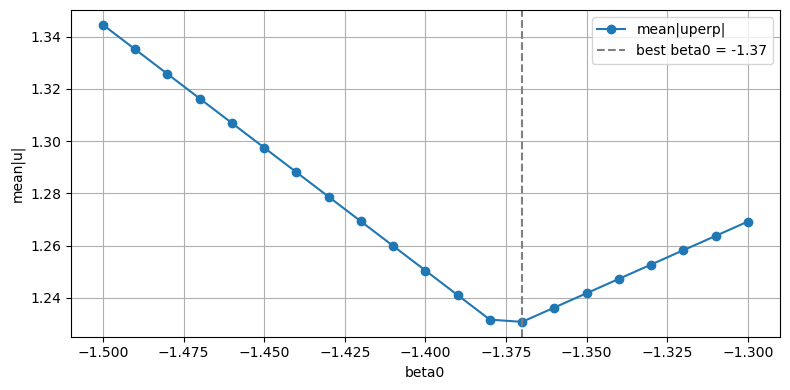

In [241]:
beta0s      = list(results.keys())
score_uperp = [results[b][0] for b in beta0s]
score_upara = [results[b][1] for b in beta0s]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(beta0s, score_uperp, marker="o", label="mean|uperp|")
ax.axvline(best_beta0, color="gray", linestyle="--", label=f"best beta0 = {best_beta0:.2f}")
ax.set_xlabel("beta0")
ax.set_ylabel("mean|u|")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#fig.savefig("beta0_determination_tbird.pdf")

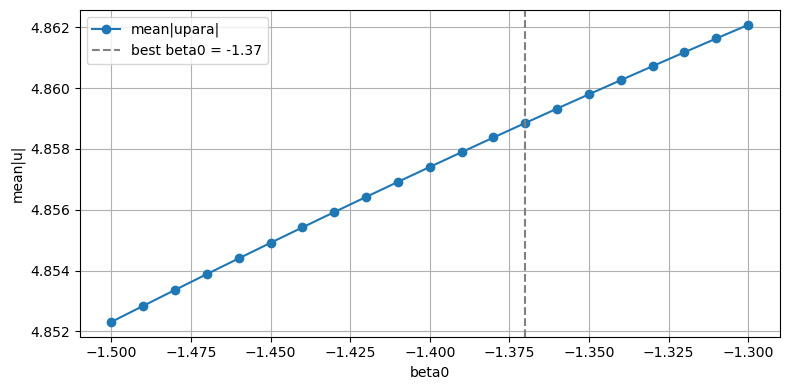

In [242]:
beta0s      = list(results.keys())
score_uperp = [results[b][0] for b in beta0s]
score_upara = [results[b][1] for b in beta0s]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(beta0s, score_upara, marker="o", label="mean|upara|")
ax.axvline(best_beta0, color="gray", linestyle="--", label=f"best beta0 = {best_beta0:.2f}")
ax.set_xlabel("beta0")
ax.set_ylabel("mean|u|")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Check for time offsets

instruments where the time is manually adjusted might have time offsets. These can be noted in the config file.

In [441]:
def check_time_shift(p1, p2, max_lag_seconds=60, plot=True):
    """
    p1, p2: xarray DataArrays with a 'time' dimension
    Detects time shift between two pressure signals via cross-correlation.
    """

    # 1. Interpolate p2 onto p1's time axis (common grid required)
    p2_interp = p2.interp(time=p1.time, method="linear")

    # 2. Remove slow trends — only fluctuations carry timing info
    #    (high-pass: subtract a rolling mean)
    window = 600  # samples; tune to your sampling rate
    p1_anom = p1 - p1.rolling(time=window, center=True, min_periods=1).mean()
    p2_anom = p2_interp - p2_interp.rolling(time=window, center=True, min_periods=1).mean()

    # 3. Drop NaNs (must be same length)
    a = p1_anom.values
    b = p2_anom.values
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]

    # 4. Normalize
    a = (a - a.mean()) / a.std()
    b = (b - b.mean()) / b.std()

    # 5. Cross-correlation
    corr = signal.correlate(a, b, mode="full")
    lags = signal.correlation_lags(len(a), len(b), mode="full")

    # Convert lags from samples to seconds
    dt = float(p1.time.diff("time").median()) / 1e9  # ns → seconds
    lags_sec = lags * dt

    # Restrict to max_lag window
    mask_lag = np.abs(lags_sec) <= max_lag_seconds
    corr_windowed = corr[mask_lag]
    lags_windowed = lags_sec[mask_lag]

        # Envelope of the cross-correlation
#    envelope = np.abs(hilbert(corr_windowed))
#    best_lag = lags_windowed[np.argmax(envelope)]
    #print(f"Lag from envelope: {best_lag:.2f} s")
    best_lag = lags_windowed[np.argmax(corr_windowed)]
    print(f"Estimated time shift: {best_lag:.2f} s  (postive → p1 leads p2, i.e. p2 needs to be shifted by {best_lag * 1000:.0f} ms)")

    if plot:
        fig, axes = plt.subplots(2, 1, figsize=(10, 6))

        axes[0].plot(p1.time, p1_anom, label="proc.p_air", alpha=0.7)
        axes[0].plot(p2_interp.time, p2_anom, label="out_ds.p_air", alpha=0.7)
        axes[0].set_ylabel("pressure anomaly")
        axes[0].legend()
        axes[0].set_title("Detrended pressure fluctuations")

        axes[1].plot(lags_windowed, corr_windowed)
        axes[1].axvline(best_lag, color="red", linestyle="--",
                        label=f"peak lag = {best_lag:.2f} s")
        axes[1].set_xlabel("lag (s)")
        axes[1].set_ylabel("cross-correlation")
        axes[1].set_title("Cross-correlation (restricted to ±{max_lag_seconds} s)")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    return best_lag

In [6]:
flight = 6
pf = "partector_tbird"
if pf == "partector_tbird":
    dev = "partector_dms_tbird"
else:
    dev = pf

In [7]:
config = h.import_dictionary(config_file)
outdir_totest = config["paths"]["outdirs"][pf]
flight_date = str(config["flights"][flight]["date"]).replace("-","")
campaign = config["campaign"]["name"]
if pf[-5:] == "tbird":
    outdir_nb = config["paths"]["outdirs"]["tbird"]
    fn_ref = outdir_nb+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_tbird_100Hz.nc"
else:
    outdir_nb = config["paths"]["outdirs"]["noseboom"]
    fn_ref = outdir_nb+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_noseboom_100Hz.nc"
fn = outdir_totest+"/"+campaign+"_"+flight_date+f"_RF{flight:02}_{pf}.nc"

ref = xr.open_dataset(fn_ref)
totest = xr.open_dataset(fn)

Estimated time shift: 0.00 s  (postive → p1 leads p2, i.e. p2 needs to be shifted by 0 ms)


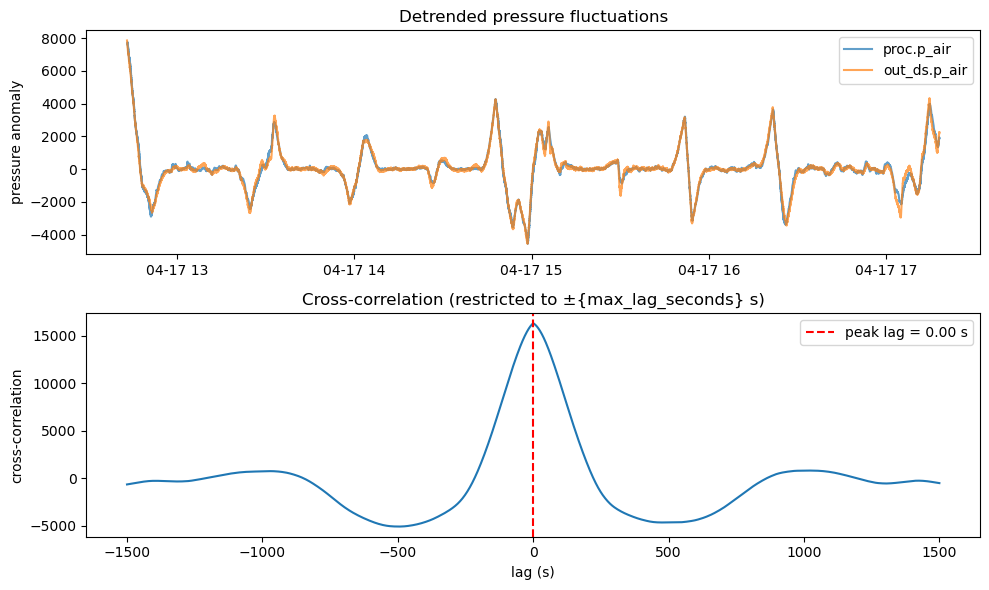

In [731]:
lag = check_time_shift(totest.p_air, ref.p_air, max_lag_seconds=1500)

# Device plots

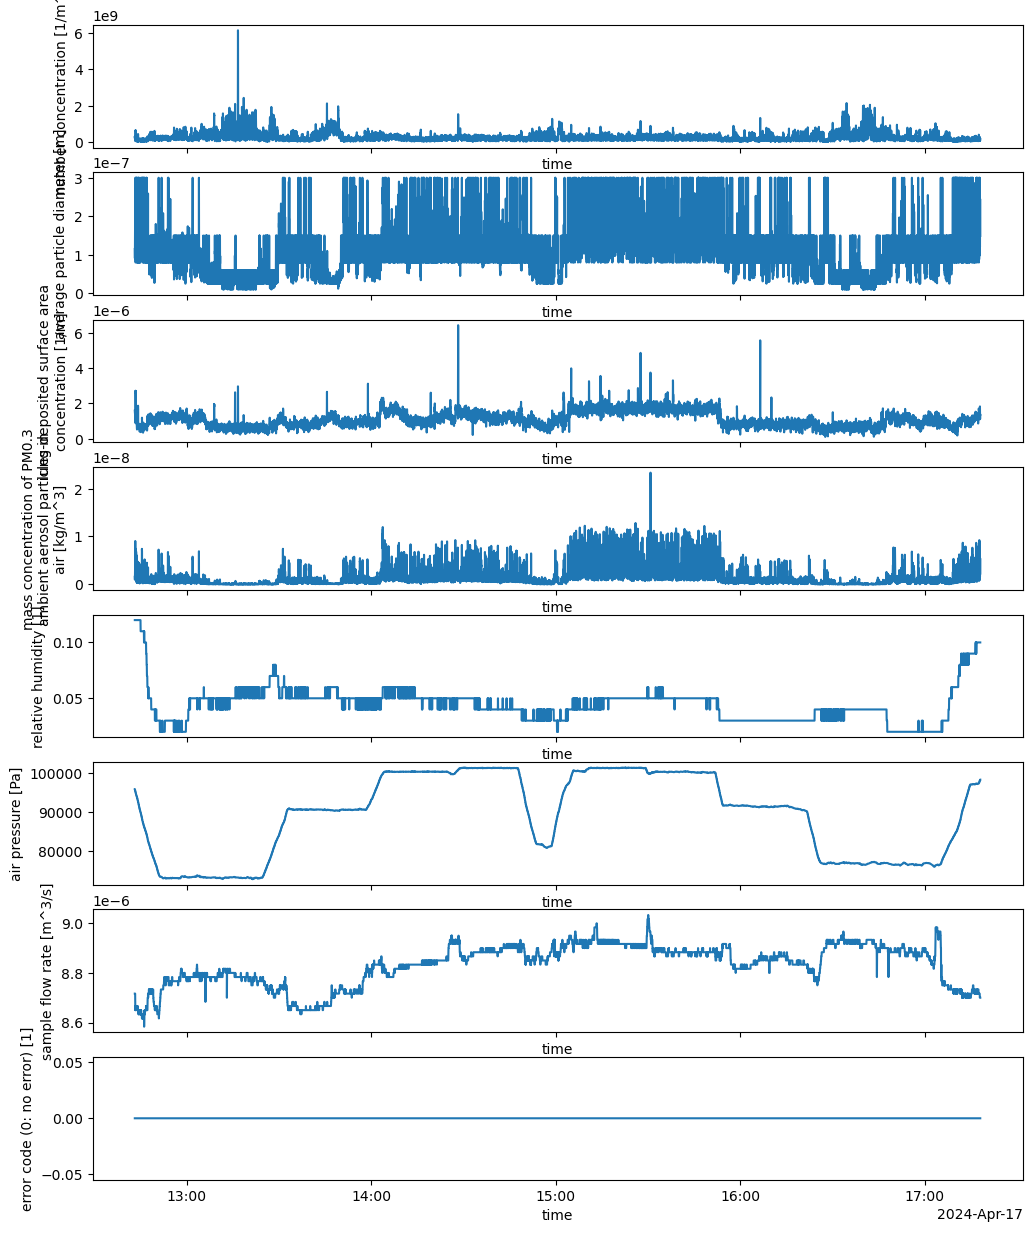

In [733]:
# Partector
fig, axs = plt.subplots(8,1,figsize=(12,15),sharex=True)

for v, ax in zip(list(totest.keys()), fig.get_axes()):
    totest[v].plot(ax = ax)

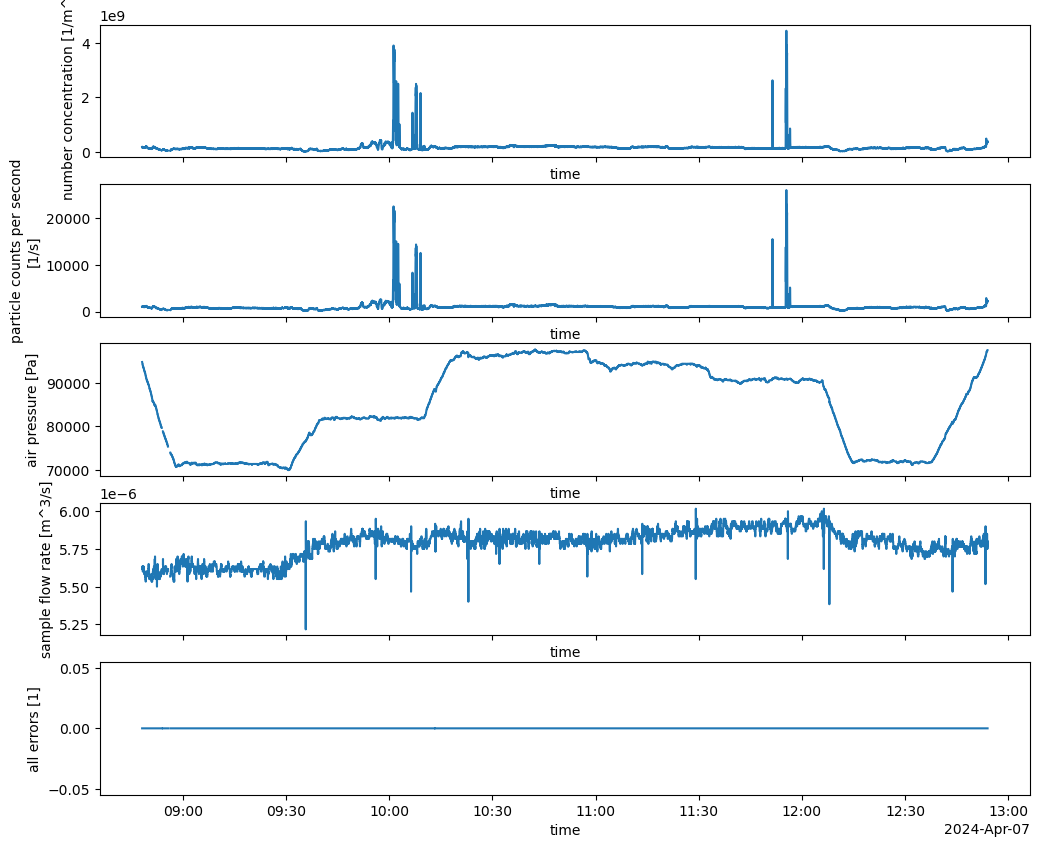

In [605]:
#MCPC
fig, axs = plt.subplots(5,1,figsize=(12,10),sharex=True)

for v, ax in zip(list(totest.keys()), fig.get_axes()):
    totest[v].plot(ax = ax)